# 03. Data Preprocessing

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand the key concepts of this topic
- Apply the topic using Python code examples
- Practice with small, realistic datasets or scenarios

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 2, lesson 07 "Encoding Categorical Features" — encoding, now joined by scaling and train/test splitting into one pipeline.

**Used later in:** Course 05 (AIAT 115) — Unit 2, lesson 04 (scaling and encoding) and Course 12 (AIAT 126) — Unit 3, which preprocesses the graduation-project dataset.

---


## 🌍 A real case: why this file's columns are called V1–V28

The `creditcard_fraud.csv` used in this notebook is a real capture: transactions made by European
cardholders over two days in September 2013, collected in a research collaboration between Worldline
and the Machine Learning Group at Université Libre de Bruxelles. 284,807 transactions, 492 of them
fraudulent — 0.172%.

Look at the column names. There are no column names. `V1` through `V28` are **principal components**:
the bank could not release the original fields, so PCA was applied *as a preprocessing step for
confidentiality* and only the transformed values were published. Exactly two columns escaped the
transformation because they carry no identifying information — `Time` and `Amount`.

**❗ Why this lesson exists.** That is why this notebook scales precisely those two columns: they are
the only two still in their original units. In our sample `Time` runs from 7 to 172,788 (seconds) and
`Amount` from \$0.00 to \$8,182.70. Any model that measures distance or follows a gradient will read
`Time` as roughly a thousand times more important than `Amount` — not because it is, but because
somebody chose to record it in seconds. Scaling is what stops the clock from outvoting the money.


# 03. Data Preprocessing

---

## The Story: Preparing Ingredients for Cooking

Imagine you're cooking. **Before** you can cook, you need to prepare ingredients - cut vegetables to the same size, marinate meat, measure spices. **After** preparing everything uniformly, you can cook a perfect meal!

Same with machine learning: **Before** building models, we preprocess data - scale features to same range, encode categories to numbers, split into train/test. **After** preprocessing, we can build accurate models!

---

## Why Data Preprocessing Matters

Preprocessing is essential for ML success:
- **Feature Scaling**: Algorithms work better when features are on similar scales
- **Encoding**: ML algorithms need numbers, not text categories
- **Train-Test Split**: We need separate data to evaluate model performance
- **Without Preprocessing**: Models fail or perform poorly

## Learning Objectives
1. Scale features using Standardization and Normalization
2. Encode categorical variables (Label vs One-Hot)
3. Split data into training and testing sets
4. Understand when to use each preprocessing method
5. Build a complete preprocessing pipeline


In [1]:
# Step 1: Import necessary libraries
# These libraries help us preprocess data for machine learning
import pandas as pd     # Data manipulation
import numpy as np      # Numerical operations
from sklearn.preprocessing import (
    StandardScaler,   # For standardization (mean=0, std=1)
    MinMaxScaler,     # For normalization (range 0-1)
    LabelEncoder,     # For ordinal encoding
    OneHotEncoder,    # For nominal encoding
)
from sklearn.model_selection import train_test_split  # For splitting data

print("Libraries imported successfully!")
print("\nWhat each preprocessing tool does:")
print(" - StandardScaler: scale features to mean=0, std=1 (z-score)")
print(" - MinMaxScaler: scale features to range [0, 1]")
print(" - LabelEncoder: convert categories to numbers (ordinal)")
print(" - OneHotEncoder: convert categories to binary columns (nominal)")
print(" - train_test_split: split data into train/test sets")

Libraries imported successfully!

What each preprocessing tool does:
 - StandardScaler: scale features to mean=0, std=1 (z-score)
 - MinMaxScaler: scale features to range [0, 1]
 - LabelEncoder: convert categories to numbers (ordinal)
 - OneHotEncoder: convert categories to binary columns (nominal)
 - train_test_split: split data into train/test sets


## Part 1: Setting the Scene

**BEFORE**: We have clean data, but it's not ready for machine learning - features have different scales, categories are text, and we haven't split the data.

**AFTER**: We'll preprocess the data - scale features, encode categories, split into train/test - making it ready for ML models!

**Why this matters**: Most ML algorithms require preprocessed data. Without it, models fail or give poor results!

---

## Step 1: Load Real-World Data

**BEFORE**: We need to learn preprocessing, but we need real data with different scales and categories.

**AFTER**: We'll load the Credit Card Fraud dataset - real transaction data with features on different scales - and add a categorical feature to practice preprocessing techniques!

**Why use Credit Card Fraud data?** This is REAL anonymized transaction data with features that need scaling (Time is in tens of thousands of seconds while Amount is in dollars). Real datasets have these characteristics - we need to learn how to handle them.

In [2]:
# Load the REAL Credit Card Fraud dataset from the local datasets folder
# Source: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
# GDI Theme: Financial Investigations - Fraud Detection
# This dataset has features on very different scales - perfect for learning preprocessing!
print("Loading Credit Card Fraud dataset...")
df_full = pd.read_csv('../../datasets/raw/creditcard_fraud.csv')
print("Real-world Credit Card Fraud data loaded from local file!")
print(f" Full dataset: {len(df_full):,} transactions x {df_full.shape[1]} columns")

# For learning, use a 20,000-transaction sample for faster execution
sample_size = 20000
df = df_full.sample(n=sample_size, random_state=57).reset_index(drop=True)
print(f" Using sample: {len(df):,} transactions (for faster learning)")
print(" Note: using a sample for learning convenience. In real projects, use the full dataset.")

# Add a categorical feature so we can practice encoding techniques:
# transaction_size, derived from Amount (Small: <= $20, Medium: $20-$100, Large: > $100)
df['transaction_size'] = pd.cut(
    df['Amount'],
    bins=[-0.01, 20, 100, np.inf],
    labels=['Small', 'Medium', 'Large'],
).astype(str)

print(f"\nWorking dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(" Numerical features: Time, Amount (V1-V28 are already PCA-scaled)")
print(" Categorical feature (created): transaction_size (Small: <= $20, Medium: $20-$100, Large: > $100)")
print(f" Target: Class {df['Class'].value_counts().to_dict()} (0=Normal, 1=Fraud)")
print("\ntransaction_size distribution:")
print(df['transaction_size'].value_counts())
print("\nFeature scales in our sample (why we need scaling!):")
print(f" Time:   {df['Time'].min():,.0f} - {df['Time'].max():,.0f} seconds")
print(f" Amount: ${df['Amount'].min():,.2f} - ${df['Amount'].max():,.2f}")

print("\nSample of key columns:")
print(df[['Time', 'Amount', 'transaction_size', 'Class']].head())

Loading Credit Card Fraud dataset...


Real-world Credit Card Fraud data loaded from local file!
 Full dataset: 284,807 transactions x 31 columns
 Using sample: 20,000 transactions (for faster learning)
 Note: using a sample for learning convenience. In real projects, use the full dataset.

Working dataset: 20,000 rows x 32 columns
 Numerical features: Time, Amount (V1-V28 are already PCA-scaled)
 Categorical feature (created): transaction_size (Small: <= $20, Medium: $20-$100, Large: > $100)
 Target: Class {0: 19968, 1: 32} (0=Normal, 1=Fraud)

transaction_size distribution:
transaction_size
Small     9690
Medium    6296
Large     4014
Name: count, dtype: int64

Feature scales in our sample (why we need scaling!):
 Time:   7 - 172,788 seconds
 Amount: $0.00 - $8,182.70

Sample of key columns:
       Time  Amount transaction_size  Class
0  111101.0    1.00            Small      0
1   77256.0  603.98            Large      0
2   60061.0   29.01           Medium      0
3  124341.0    4.49            Small      0
4   38132.0   

## 📊 Understanding the Dataset

### For CS Students - Focus on Data Structure, Not Domain

**As computer science students, you'll work with many different types of datasets** (medical, financial, security, e-commerce, etc.). **What matters is the data structure, not the domain knowledge!**

**Data Structure Focus**:
- **Data Shape**: 20,000 rows × 32 columns (sample of transactions × features: 31 original columns + the `transaction_size` column we add for encoding practice)
  - Note: We use a sample for learning convenience (faster execution)
  - Full dataset has ~284,000 rows - would be slower but more representative
- **Feature Types**: Mixed (numerical: Time, Amount, V1-V28; categorical: transaction_size)
- **Target Type**: Classification (binary: 0=Normal, 1=Fraud)
- **Task**: Detect fraudulent transactions based on features
- **Preprocessing Needs**: Features on different scales (Time, Amount need scaling), categorical feature (need encoding)

**Why This Structure Matters**:
- **Different feature scales** → Need standardization/normalization (in our sample, Time spans 7-172,788 seconds while Amount spans $0-$8,182.70)
- **Categorical feature** → Need encoding (transaction_size: Small/Medium/Large → numbers)
- **Classification task** → Binary classification (fraud detection)
- **Large dataset** → Good for train/test split demonstration
- **V1-V28 already scaled** → These are PCA-transformed features (already standardized), so we focus on Time and Amount

### Understanding the Dataset Domain (Brief)

**What is this data?** Real anonymized credit card transaction data for fraud detection (GDI Theme: Financial Investigations).

**Why does this matter?** 
- **For scaling**: Features have very different scales (Time: seconds in thousands, Amount: dollars) → need standardization/normalization
- **For encoding**: transaction_size is categorical (Small/Medium/Large) → need encoding for ML
- **For train/test split**: Need separate data to evaluate model performance
- **For fraud detection**: Financial investigation context - detecting suspicious transactions

**Domain Context** (Brief):
- **Time**: Time elapsed between transaction and first transaction (seconds) - helps detect patterns
- **Amount**: Transaction amount (dollars) - important for fraud detection
- **V1-V28**: PCA-transformed features (anonymized to protect privacy, already scaled)
- **Class**: Target variable (0=Normal transaction, 1=Fraudulent transaction)
- **transaction_size**: Categorical feature we created from Amount (Small/Medium/Large) - demonstrates encoding
  - Note: This is created for learning encoding techniques only
  - In real modeling, you wouldn't create categories from a feature you're already using
  - It's just for demonstration purposes to show how encoding works!

**💡 Key Point for CS Students**: You don't need to be a financial expert! Focus on:
- Understanding the **data structure** (rows, columns, types, scales)
- Knowing the **preprocessing methods** (scaling vs. encoding)
- Choosing the right **preprocessing approach** based on structure, not domain knowledge

In [3]:
print("=" * 60)
print("2. Feature Scaling - Standardization")
print("=" * 60)

2. Feature Scaling - Standardization


## Step 2: Feature Scaling - Standardization

**BEFORE**: Features have very different scales (age: 20-60, salary: 30k-100k). Algorithms will be biased toward larger numbers!

**AFTER**: We'll standardize features so they all have mean=0 and std=1, putting them on the same scale!

**Why Standardization?**
- **Problem**: Features have different scales (age: 20-60, salary: 30k-100k)
- **Issue**: ML algorithms treat larger numbers as more important → biased toward salary!
- **Solution**: Standardization puts all features on same scale (mean=0, std=1)
- **Result**: All features contribute equally to the model
- **Formula**: `(x - mean) / std`

**Why mean=0 and std=1? (Common Student Questions)**

**Q: Why mean=0, not 1 or 100?**
- **Answer**: We subtract the mean → `(x - mean)` centers data at 0
  - If mean=40: value=50 becomes (50-40)=10, value=30 becomes (30-40)=-10
  - The average of all (x - mean) values is always 0 (by definition!)
  - Mean=0 means data is centered (balanced around zero)
  - Why not 1? Because subtracting mean naturally gives 0, not 1

**Q: Why std=1, not 0 or 2?**
- **Answer**: We divide by std → `(x - mean) / std` normalizes spread to 1
  - If std=10: value=50 becomes (50-40)/10=1.0, value=30 becomes (30-40)/10=-1.0
  - Dividing by std makes the new std exactly 1 (by definition!)
  - Std=1 means "one unit of variation" (standard unit)
  - Why not 0? Std=0 means no variation (all values same) - not useful!
  - Why not 2? We want standard unit (1), not arbitrary number

**Q: Why these specific numbers (0 and 1)?**
- **Answer**: They're the "standard" values that make comparison easy
  - Mean=0: Easy to see if value is above/below average (positive/negative)
  - Std=1: Easy to see how many standard deviations away (1.5 = 1.5 std away)
  - Together: All features use same "standard scale" for fair comparison

- **Use when**: Data is normally distributed, outliers are important
- **Good for**: Linear models, neural networks, distance-based algorithms

**Note**: Remove problematic outliers first (Example 2), then standardize. Standardization preserves outliers, so clean data first!

In [4]:
# Create StandardScaler object
# Standardization formula: (x - mean) / std
# - .fit(): learns the mean and std from the data
# - .transform(): applies (x - learned_mean) / learned_std
# - .fit_transform(): does both in one step
# - In real ML: fit on TRAINING data only, then transform train and test (don't refit!)
scaler_standard = StandardScaler()

print("StandardScaler created")
print(" Formula: (x - mean) / std")

StandardScaler created
 Formula: (x - mean) / std


In [5]:
# Select numeric columns for scaling
# Why only these? Categorical columns need encoding, not scaling,
# and V1-V28 are already scaled via PCA - so we focus on Time and Amount
numeric_cols = ['Time', 'Amount']
df_scaled_standard = df.copy()

print(f"Scaling columns: {numeric_cols}")
print(" (V1-V28 are already scaled via PCA, so we focus on Time and Amount)")

Scaling columns: ['Time', 'Amount']
 (V1-V28 are already scaled via PCA, so we focus on Time and Amount)


In [6]:
# Fit and transform the data
# .fit_transform() learns the mean/std from the data, then transforms it
print("Before Standardization:")
print(f" Time   - Mean: {df['Time'].mean():.2f}, Std: {df['Time'].std():.2f}")
print(f" Amount - Mean: {df['Amount'].mean():.2f}, Std: {df['Amount'].std():.2f}")

df_scaled_standard[numeric_cols] = scaler_standard.fit_transform(df[numeric_cols])

print("\nAfter Standardization (mean=0, std=1):")
print(f" Time   - Mean: {df_scaled_standard['Time'].mean():.4f}, Std: {df_scaled_standard['Time'].std():.4f}")
print(f" Amount - Mean: {df_scaled_standard['Amount'].mean():.4f}, Std: {df_scaled_standard['Amount'].std():.4f}")
print("\nAll scaled features now have mean~0 and std~1!")
print("\nUnderstanding the values:")
print(" - Positive values (e.g., 1.67): above average (1.67 std above the mean)")
print(" - Negative values (e.g., -1.36): below average (1.36 std below the mean)")
print(" - Values near 0: close to average")
print("\nSample of standardized features:")
print(df_scaled_standard[numeric_cols].head().round(4))

Before Standardization:
 Time   - Mean: 94510.45, Std: 47563.13
 Amount - Mean: 90.91, Std: 264.67

After Standardization (mean=0, std=1):
 Time   - Mean: -0.0000, Std: 1.0000
 Amount - Mean: -0.0000, Std: 1.0000

All scaled features now have mean~0 and std~1!

Understanding the values:
 - Positive values (e.g., 1.67): above average (1.67 std above the mean)
 - Negative values (e.g., -1.36): below average (1.36 std below the mean)
 - Values near 0: close to average

Sample of standardized features:
     Time  Amount
0  0.3488 -0.3397
1 -0.3628  1.9386
2 -0.7243 -0.2339
3  0.6272 -0.3265
4 -1.1854 -0.3397


## Step 3: Feature Scaling - Normalization (Min-Max)

**BEFORE**: Features have different ranges. We want them all in the same range [0, 1].

**AFTER**: We'll normalize features so they all range from 0 to 1!

**Why Normalization (Min-Max)?**
- **Problem**: Same as standardization - different scales
- **Solution**: Normalization puts all features in range [0, 1]
- **Formula**: `(x - min) / (max - min)`
- **Result**: Range [0, 1] (minimum becomes 0, maximum becomes 1)

**Common Student Questions:**
- **Q: Why range [0, 1], not [0, 100]?**
  - Answer: [0, 1] is standard range (0% to 100% of the spread)
  - Easy to interpret: 0 = minimum, 1 = maximum, 0.5 = middle
- **Q: Why not use standardization?**
  - Answer: Normalization gives bounded [0,1] range (good for neural networks)
  - Standardization can give values outside [0,1] (e.g., -2.5, 3.1)
- **Q: Which is better?**
  - Answer: Depends on your algorithm!
  - Standardization: Better for normal data, preserves outliers
  - Normalization: Better for neural networks, bounded range needed

- **Use when**: Data is not normally distributed, you want bounded values
- **Good for**: Neural networks, algorithms that need [0,1] range

In [7]:
# Normalization: (x - min) / (max - min) -> range [0, 1]
# MinMaxScaler learns min and max with .fit(), then transforms with .transform()
# (or use .fit_transform() to do both in one step)
scaler_minmax = MinMaxScaler()
df_scaled_minmax = df.copy()
df_scaled_minmax[numeric_cols] = scaler_minmax.fit_transform(df[numeric_cols])

print("After Min-Max Normalization (range 0-1):")
print(f" Time   - Min: {df_scaled_minmax['Time'].min():.4f}, Max: {df_scaled_minmax['Time'].max():.4f}")
print(f" Amount - Min: {df_scaled_minmax['Amount'].min():.4f}, Max: {df_scaled_minmax['Amount'].max():.4f}")
print("\nSample of normalized features:")
print(df_scaled_minmax[numeric_cols].head().round(4))

After Min-Max Normalization (range 0-1):
 Time   - Min: 0.0000, Max: 1.0000
 Amount - Min: 0.0000, Max: 1.0000

Sample of normalized features:
     Time  Amount
0  0.6430  0.0001
1  0.4471  0.0738
2  0.3476  0.0035
3  0.7196  0.0005
4  0.2207  0.0001


### Step 3b: See What Each Scaler Actually Did

**BEFORE**: The printouts say standardization gave mean 0 / std 1 and min-max gave the range
[0, 1]. Both report success.

**AFTER**: We draw the two columns before and after each scaler, and find that "the summary numbers
look right" and "the two columns are now comparable" are **not the same statement**.

/var/folders/7n/l2c2z2x57871xg4f_0drsv1m0000gn/T/ipykernel_3837/2260552827.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([series_amount, series_time], vert=False,
/var/folders/7n/l2c2z2x57871xg4f_0drsv1m0000gn/T/ipykernel_3837/2260552827.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([series_amount, series_time], vert=False,
/var/folders/7n/l2c2z2x57871xg4f_0drsv1m0000gn/T/ipykernel_3837/2260552827.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([series_amount, series_time], vert=False,


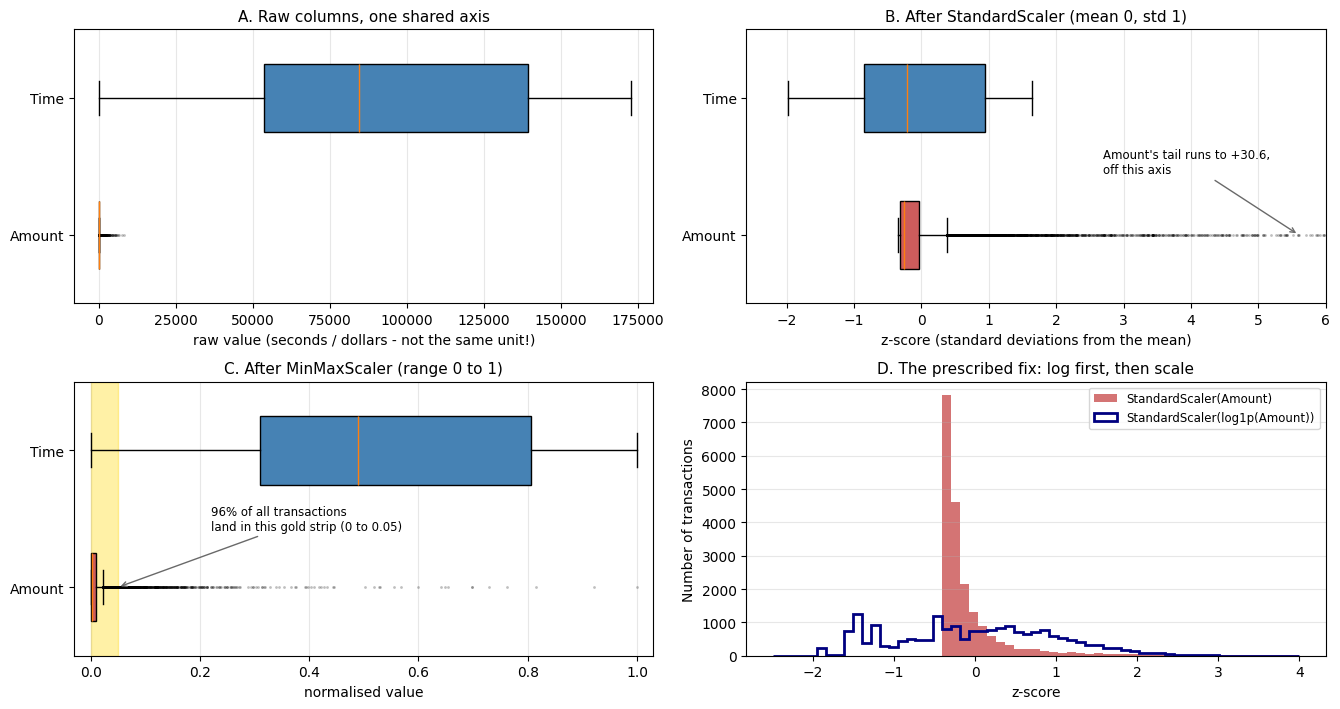

Width of the middle 50% of each column (Q3 - Q1) - i.e. the width of the box:
  raw             Time  85,664.2500   Amount    74.0125   ratio Time/Amount = 1157.4x
  standardised    Time       1.8011   Amount     0.2796   ratio Time/Amount =    6.4x
  min-max scaled  Time       0.4958   Amount     0.0090   ratio Time/Amount =   54.8x

Share of transactions inside [-1, +1] after scaling:
  StandardScaler(Amount)         : 94.8%
  StandardScaler(log1p(Amount))  : 63.4%


In [8]:
# CELL: Draw Time and Amount before and after each scaler, on the same axis each time.
# WHY: a scaler's printout can only report its own definition back to you - StandardScaler
#      will ALWAYS say mean=0, std=1, MinMaxScaler will ALWAYS say 0 to 1. Whether the two
#      columns actually became comparable is a question only the picture answers.
import matplotlib.pyplot as plt

def two_boxes(ax, series_time, series_amount, title, xlabel):
    """One panel: Time and Amount as horizontal boxplots on ONE shared x-axis."""
    bp = ax.boxplot([series_amount, series_time], vert=False,
                    labels=['Amount', 'Time'], patch_artist=True, widths=0.5,
                    flierprops=dict(marker='.', markersize=2, alpha=0.25))
    for patch, colour in zip(bp['boxes'], ['indianred', 'steelblue']):
        patch.set_facecolor(colour)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xlabel)
    ax.grid(axis='x', alpha=0.3)
    return bp

fig, axes = plt.subplots(2, 2, figsize=(13.5, 7.2))

# --- A: the raw columns -------------------------------------------------------------
two_boxes(axes[0, 0], df['Time'], df['Amount'],
          'A. Raw columns, one shared axis', 'raw value (seconds / dollars - not the same unit!)')
axes[0, 0].set_xlim(-8000, 180000)

# --- B: after StandardScaler --------------------------------------------------------
two_boxes(axes[0, 1], df_scaled_standard['Time'], df_scaled_standard['Amount'],
          'B. After StandardScaler (mean 0, std 1)', 'z-score (standard deviations from the mean)')
axes[0, 1].set_xlim(-2.6, 6)
axes[0, 1].annotate(f"Amount's tail runs to +{df_scaled_standard['Amount'].max():.1f},\noff this axis",
                    xy=(5.6, 1), xytext=(2.7, 1.45), fontsize=8.5,
                    arrowprops=dict(arrowstyle='->', color='dimgray'))

# --- C: after MinMaxScaler ----------------------------------------------------------
two_boxes(axes[1, 0], df_scaled_minmax['Time'], df_scaled_minmax['Amount'],
          'C. After MinMaxScaler (range 0 to 1)', 'normalised value')
axes[1, 0].set_xlim(-0.03, 1.03)
share_low = (df_scaled_minmax['Amount'] < 0.05).mean() * 100
axes[1, 0].axvspan(0, 0.05, color='gold', alpha=0.35)
axes[1, 0].annotate(f'{share_low:.0f}% of all transactions\nland in this gold strip (0 to 0.05)',
                    xy=(0.05, 1.0), xytext=(0.22, 1.42), fontsize=8.5,
                    arrowprops=dict(arrowstyle='->', color='dimgray'))

# --- D: the fix the lesson recommends - log first, then scale ------------------------
# WHY this panel: "Where this breaks" prescribes log1p(Amount) before scaling. This shows
# what that prescription buys, with both versions as z-scores on ONE axis.
ax = axes[1, 1]
z_amount = df_scaled_standard['Amount']
z_log_amount = StandardScaler().fit_transform(np.log1p(df[['Amount']]))[:, 0]
bins = np.linspace(-2.5, 4, 60)
ax.hist(z_amount, bins=bins, color='indianred', alpha=0.85,
        label='StandardScaler(Amount)')
ax.hist(z_log_amount, bins=bins, histtype='step', color='navy', linewidth=2,
        label='StandardScaler(log1p(Amount))')
ax.set_title('D. The prescribed fix: log first, then scale', fontsize=11)
ax.set_xlabel('z-score')
ax.set_ylabel('Number of transactions')
ax.legend(fontsize=8.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# The numbers behind the picture: box width = the middle 50% of the column.
print("Width of the middle 50% of each column (Q3 - Q1) - i.e. the width of the box:")
for name, frame in [('raw            ', df),
                    ('standardised   ', df_scaled_standard),
                    ('min-max scaled ', df_scaled_minmax)]:
    wt = frame['Time'].quantile(0.75) - frame['Time'].quantile(0.25)
    wa = frame['Amount'].quantile(0.75) - frame['Amount'].quantile(0.25)
    print(f"  {name} Time {wt:>12,.4f}   Amount {wa:>10,.4f}   ratio Time/Amount = {wt / wa:6.1f}x")
print(f"\nShare of transactions inside [-1, +1] after scaling:")
print(f"  StandardScaler(Amount)         : {((z_amount > -1) & (z_amount < 1)).mean() * 100:.1f}%")
print(f"  StandardScaler(log1p(Amount))  : {((z_log_amount > -1) & (z_log_amount < 1)).mean() * 100:.1f}%")

**Read the figure.**

*Panel A — why we scale at all.* On one shared axis, `Time` (blue) stretches across the whole plot
and `Amount` (red) is a stripe pinned against zero. The two columns are not even in the same unit —
seconds and dollars — and any algorithm that measures distance would let `Time` decide everything.

*Panel B — StandardScaler.* Both boxes are now centred near zero, so the summary printout is
correct. But look at the **widths**: the middle 50% of `Time` spans about 1.8 z-units, the middle
50% of `Amount` spans about 0.28 — still roughly 6× narrower — and `Amount`'s whiskers run out to
+30.6, far off the right of this axis.

*Panel C — MinMaxScaler, and this is the one to remember.* The printout said `Amount: min 0.0000,
max 1.0000`, which sounds like a job done. The gold strip is the bottom 5% of that range, and
**95.6% of all 20,000 transactions are inside it**. A single $8,182.70 transaction defined the
maximum and squashed everything else into a sliver. This is the second bullet of
**⚠️ Where this breaks**, drawn.

*Panel D — the fix, and why it works.* Red is `Amount` standardised directly: a single tower near
−0.3 holding almost every transaction. Navy is `log1p(Amount)` standardised: a broad, usable
distribution spread over roughly −1.9 to +3.5. **Scaling changes the units of a column; it does not
change its shape.** If the shape is the problem, the transform has to come first.

## Step 4: Label Encoding

**BEFORE**: We have categorical text data (e.g., 'Small', 'Medium', 'Large' transaction sizes), but ML algorithms need numbers!

**AFTER**: We'll encode categories to numbers using Label Encoding - perfect for ordinal categories (categories with order)!

**Common Student Questions:**
- **Q: What is ordinal vs nominal?**
  - Answer: Ordinal = categories have order (e.g., Small < Medium < Large, Low < Medium < High)
  - Nominal = categories have no order (e.g., city names, colors, departments)
  - Label encoding preserves order → use for ordinal
  - One-hot encoding treats all equally → use for nominal
- **Q: Why use Label Encoding instead of One-Hot?**
  - Answer: Label encoding preserves the order relationship
  - Example: Small=0, Medium=1, Large=2 → algorithm knows Large > Medium > Small
  - One-hot would create 3 separate columns → loses the order information
  - Use label encoding when order matters (transaction sizes, ratings, sizes)
- **Q: Can I use Label Encoding for nominal categories?**
  - Answer: Technically yes, but NOT recommended!
  - Problem: Creates false order (e.g., 'Red'=0, 'Blue'=1, 'Green'=2 → algorithm thinks Green > Blue > Red)
  - Solution: Use One-Hot Encoding for nominal categories (no false order)
- **Q: How does LabelEncoder assign numbers?**
  - Answer: Assigns numbers in alphabetical order (or order found in data)
  - Example: ['Large', 'Medium', 'Small'] → Large=0, Medium=1, Small=2 (alphabetical)
  - Important: Order might not match your desired order → check `label_encoder.classes_`
- **Q: What if I want a specific order?**
  - Answer: You can manually map categories to numbers using a dictionary
  - Example: `df['transaction_size'] = df['transaction_size'].map({'Small': 0, 'Medium': 1, 'Large': 2})`
  - Or use pandas `Categorical` with `ordered=True` to control order

**Use when**: Categories have inherent order (ordinal data)
**Good for**: Transaction sizes, ratings, sizes, rankings (transaction_size: Small < Medium < Large)

In [9]:
# LabelEncoder()
# - Creates an encoder for ordinal categorical data
# - Ordinal: categories have order (e.g., Small < Medium < Large)
# - Converts text categories to integers (0, 1, 2, ...)
# - .fit(): learn unique categories; .transform(): convert to numbers
# - Or use .fit_transform(): do both in one step
label_encoder = LabelEncoder()

print("LabelEncoder created")

LabelEncoder created


In [10]:
# Encode transaction_size (ordinal: Small < Medium < Large)
df_encoded = df.copy()
df_encoded['transaction_size_encoded'] = label_encoder.fit_transform(df['transaction_size'])

# label_encoder.classes_ shows the mapping (categories in encoded order)
print("Label Encoding for Transaction Size:")
for i, label in enumerate(label_encoder.classes_):
    print(f" {label} -> {i}")

print("\nNote: LabelEncoder assigns numbers ALPHABETICALLY (Large=0, Medium=1, Small=2),")
print("which does NOT match the natural order Small < Medium < Large!")
print("For a specific order, map manually: {'Small': 0, 'Medium': 1, 'Large': 2}")

print("\nSample of encoded data:")
print(df_encoded[['Amount', 'transaction_size', 'transaction_size_encoded']].head(10))

Label Encoding for Transaction Size:
 Large -> 0
 Medium -> 1
 Small -> 2

Note: LabelEncoder assigns numbers ALPHABETICALLY (Large=0, Medium=1, Small=2),
which does NOT match the natural order Small < Medium < Large!
For a specific order, map manually: {'Small': 0, 'Medium': 1, 'Large': 2}

Sample of encoded data:
   Amount transaction_size  transaction_size_encoded
0    1.00            Small                         2
1  603.98            Large                         0
2   29.01           Medium                         1
3    4.49            Small                         2
4    1.00            Small                         2
5    0.89            Small                         2
6   12.13            Small                         2
7   30.00           Medium                         1
8  436.00            Large                         0
9   19.02            Small                         2


## 💬 Discuss

1. **`LabelEncoder` assigned Large=0, Medium=1, Small=2** — alphabetical, and backwards. For a
   *decision tree*, does that wrong ordering actually cost anything? For *linear regression*? Argue
   both sides, then say when you would accept `LabelEncoder` on an unordered category anyway.

2. **We scaled `Time` and `Amount` but left `V1`–`V28` alone**, because they came out of a PCA.
   Is that defensible, or should every numeric column pass through the same scaler? Name what goes
   wrong in each direction.

3. **Read the code carefully.** In Step 2 the scaler is fit on the whole dataframe; the train/test
   split does not happen until Step 6. The comment in the cell says to fit on training data only.
   Which is right, how large would the difference be on these 20,000 rows, and would your answer
   change if the dataset had 200 rows?


## Step 5: One-Hot Encoding

**BEFORE**: We have nominal categories (no order, like city names), but ML algorithms need numbers!

**AFTER**: We'll encode categories using One-Hot Encoding - creates separate binary columns for each category!

**Common Student Questions:**
- **Q: What is One-Hot Encoding?**
  - Answer: Each category becomes a separate binary column (0 or 1)
  - Example: City ['Riyadh', 'Jeddah', 'Dammam'] → 3 columns: city_Riyadh, city_Jeddah, city_Dammam
  - Each row has 1 in one column (the city), 0 in all others
  - No false order → perfect for nominal categories
- **Q: Why use One-Hot instead of Label Encoding?**
  - Answer: One-Hot treats all categories equally (no false order)
  - Label encoding creates false order for nominal data (e.g., 'Red'=0, 'Blue'=1 → algorithm thinks Blue > Red)
  - One-Hot: Each category is independent → no order assumptions
  - Use One-Hot for: City names, colors, departments, any categories without order
- **Q: Why does One-Hot create so many columns?**
  - Answer: Each category needs its own column to represent it independently
  - Example: 10 cities → 10 columns (or 9 if using drop='first')
  - Trade-off: More columns = more memory, but no false order
  - Solution: For many categories (>50), consider Target Encoding or Frequency Encoding
- **Q: What is drop='first' in sklearn OneHotEncoder?**
  - Answer: Drops the first category column to avoid multicollinearity
  - Problem: If you have N categories, you only need N-1 columns (one is redundant)
  - Example: 4 cities → 3 columns (can infer 4th from the other 3)
  - Why: Prevents perfect correlation between columns (helps with linear models)
- **Q: When should I use pandas get_dummies vs sklearn OneHotEncoder?**
  - Answer: pandas get_dummies = easier, good for quick work
  - sklearn OneHotEncoder = more control (drop='first', sparse matrices, better for pipelines)
  - Use pandas: Quick prototyping, simple cases
  - Use sklearn: Production code, need drop='first', building pipelines

**Use when**: Categories have no inherent order (nominal data)
**Good for**: City names, colors, departments, any categories without order

In [11]:
# Method 1: Using pandas get_dummies (easier)
# - pd.get_dummies(): creates one binary column (0 or 1) per category
# - columns=['transaction_size']: the column to encode
# - prefix=['txn_size']: prefix for the new column names
# - dtype=int: store 0/1 integers (default is True/False booleans)
df_onehot = pd.get_dummies(df, columns=['transaction_size'], prefix=['txn_size'], dtype=int)

onehot_cols = [col for col in df_onehot.columns if 'txn_size_' in col]
print("One-Hot Encoded columns:")
print(f"New columns: {onehot_cols}")

print("\nSample of One-Hot Encoded data:")
sample_cols = ['Time', 'Amount'] + onehot_cols
print(df_onehot[sample_cols].head())
print("\nEach row has 1 in exactly one txn_size column (its category), 0 in the others")

One-Hot Encoded columns:
New columns: ['txn_size_Large', 'txn_size_Medium', 'txn_size_Small']

Sample of One-Hot Encoded data:
       Time  Amount  txn_size_Large  txn_size_Medium  txn_size_Small
0  111101.0    1.00               0                0               1
1   77256.0  603.98               1                0               0
2   60061.0   29.01               0                1               0
3  124341.0    4.49               0                0               1
4   38132.0    1.00               0                0               1

Each row has 1 in exactly one txn_size column (its category), 0 in the others


In [12]:
# Method 2: Using sklearn OneHotEncoder (for more control)
# Why sklearn? More control - drop='first' removes one redundant column
# (it can be inferred from the others), which avoids multicollinearity
print("--- Using sklearn OneHotEncoder ---")
onehot_encoder = OneHotEncoder(sparse_output=False, drop='first')

# OneHotEncoder expects 2D input, so we pass a DataFrame (double brackets)
txn_size_encoded = onehot_encoder.fit_transform(df[['transaction_size']])

print(" Transaction Size encoding classes:")
print(f" {onehot_encoder.categories_}")
print(f"\n Encoded shape: {txn_size_encoded.shape}")
print(" (3 transaction sizes -> 2 columns, because drop='first' removes one)")
print("\n First 5 encoded values (columns: Medium, Small):")
print(txn_size_encoded[:5])
print("\n A row of all zeros means the dropped first category ('Large')")

--- Using sklearn OneHotEncoder ---
 Transaction Size encoding classes:
 [array(['Large', 'Medium', 'Small'], dtype=object)]

 Encoded shape: (20000, 2)
 (3 transaction sizes -> 2 columns, because drop='first' removes one)

 First 5 encoded values (columns: Medium, Small):
[[0. 1.]
 [0. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]]

 A row of all zeros means the dropped first category ('Large')


## Step 6: Train-Test Split

**BEFORE**: We have all our data together. We can't evaluate model performance on data it has seen!

**AFTER**: We'll split data into training (80%) and testing (20%) sets!

**Why Train-Test Split?**
- **Training set**: Used to fit the model - this is the only data the model learns its parameters from
- **Test set**: Used **once**, at the very end, to report honest performance on data nobody tuned against
- **Validation set** (arrives in Unit 2, and is used for real in Unit 5 lesson 01): a *third* slice used to compare models and pick hyperparameters. It exists so that choosing does not consume the test set. The diploma uses these three words in exactly this way from here to Course 12 - if a step *chooses* something, it belongs on validation data, never on the test set
- **Why separate?** Testing on training data gives false high scores (overfitting)
- **Standard split**: 80% train, 20% test (can vary based on dataset size)

**Common Student Questions:**
- **Q: Why split data into train and test?**
  - Answer: Need unseen data to evaluate model performance honestly
  - Problem: Testing on training data = model memorized data → gives false high scores
  - Solution: Train on 80%, test on 20% → see how model performs on new data
  - Real-world: Model must work on data it hasn't seen before!
- **Q: Why 80/20 split?**
  - Answer: Good balance between training (need enough to learn) and testing (need enough to evaluate)
  - 80% training: Enough data for model to learn patterns
  - 20% testing: Enough data for reliable performance evaluation
  - Can adjust: Small datasets (<1000) → 70/30, Large datasets (>10k) → 90/10
- **Q: What is random_state?**
  - Answer: Seed for random number generator → ensures same split every time
  - Problem: Without seed, different split each run → can't reproduce results
  - Solution: Set random_state=57 → same split every time (reproducibility)
  - Note: We use 57 here (not 42) - different projects use different seeds for variety
  - Important: Use same random_state within one project to compare fairly
- **Q: What is stratify=y?**
  - Answer: Maintains class distribution in train/test sets
  - Problem: Random split might create imbalanced train/test (e.g., 60% class 0 in train, 40% in test)
  - Solution: stratify=y → train and test have same class distribution
  - Example: If 60% class 0, 40% class 1 → both train and test have 60/40 split
  - Use when: Classification problems with imbalanced classes
- **Q: Should I split before or after preprocessing?**
  - Answer: Split FIRST, then preprocess train and test separately!
  - Why: Fit scaler/encoder on training data only, then transform both train and test
  - Problem: Preprocessing before split = data leakage (test data influences training)
  - Correct order: Split → Fit on train → Transform train and test
  - Note: In this notebook, we show preprocessing on full data for simplicity, but in real projects, split first!

In [13]:
# Prepare features and target
# For fraud detection, we use Time and Amount as features (V1-V28 are already PCA-transformed)
# Target: Class (0=Normal, 1=Fraud)
X = df[['Time', 'Amount']]
y = df['Class']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Target distribution: {y.value_counts().to_dict()}")

Features (X) shape: (20000, 2)
Target (y) shape: (20000,)
Target distribution: {0: 19968, 1: 32}


In [14]:
# Split into train and test sets (80% train, 20% test)
# - test_size=0.2: 20% for testing, 80% for training
# - random_state=57: same split every time (we use 57 for variety across notebooks)
# - stratify=y: maintains the class distribution in train and test
#   (important for imbalanced datasets like fraud detection!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=57,
    stratify=y,
)

print(f"Original data shape: {X.shape}")
print("\nTraining set:")
print(f" X_train: {X_train.shape}")
print(f" y_train: {y_train.shape}")
print("\nTest set:")
print(f" X_test: {X_test.shape}")
print(f" y_test: {y_test.shape}")
print(f"\nTrain percentage: {len(X_train) / len(X) * 100:.1f}%")
print(f"Test percentage: {len(X_test) / len(X) * 100:.1f}%")
print("\nStratification check (fraud ratio stays the same):")
print(f" Full data: {y.mean() * 100:.3f}% fraud")
print(f" Train:     {y_train.mean() * 100:.3f}% fraud")
print(f" Test:      {y_test.mean() * 100:.3f}% fraud")

Original data shape: (20000, 2)

Training set:
 X_train: (16000, 2)
 y_train: (16000,)

Test set:
 X_test: (4000, 2)
 y_test: (4000,)

Train percentage: 80.0%
Test percentage: 20.0%

Stratification check (fraud ratio stays the same):
 Full data: 0.160% fraud
 Train:     0.163% fraud
 Test:      0.150% fraud


## Step 7: Complete Preprocessing Pipeline

**BEFORE**: We've learned individual preprocessing steps, but how do we combine them all together?

**AFTER**: We'll create a complete preprocessing pipeline that combines all steps - encoding, scaling, and splitting - into one reusable function!

**Why this matters**: In real projects, you need to apply the same preprocessing to training and test data consistently!

In [15]:
# CELL: Wrap the whole preprocessing recipe into one reusable function.
# WHY: bundling encode -> scale -> split into a single pipeline makes the steps
# repeatable on new data and much harder to apply in the wrong order.
print("=" * 60)
print("7. Complete Preprocessing Pipeline")
print("=" * 60)


def preprocess_data(df, numeric_cols, categorical_cols, target_col, test_size=0.2):
    """Complete preprocessing pipeline: encode, scale, and split.

    Course 04, Unit 1, Example 03 - Data Preprocessing.
    Returns X_train, X_test, y_train, y_test, and the fitted scaler.
    """
    # 1. Separate features and target
    X = df[numeric_cols + categorical_cols].copy()
    y = df[target_col].copy()

    # 2. Encode categorical columns (one-hot, drop first to avoid multicollinearity)
    X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=int)

    # 3. Scale numeric columns
    # (Simplified for teaching: in real projects, SPLIT FIRST, fit the scaler
    #  on the training data only, then transform train and test separately.)
    scaler = StandardScaler()
    X_encoded[numeric_cols] = scaler.fit_transform(X_encoded[numeric_cols])

    # 4. Split into train and test (stratified: keeps the class distribution)
    X_train, X_test, y_train, y_test = train_test_split(
        X_encoded, y, test_size=test_size, random_state=57, stratify=y,
    )
    return X_train, X_test, y_train, y_test, scaler


# Run the full pipeline on our fraud dataset
X_train, X_test, y_train, y_test, scaler = preprocess_data(
    df,
    numeric_cols=['Time', 'Amount'],
    categorical_cols=['transaction_size'],
    target_col='Class',
)

print("\nPipeline complete!")
print(f" X_train: {X_train.shape} (scaled numerics + encoded categories)")
print(f" X_test:  {X_test.shape}")
print(f" y_train: {y_train.shape}, y_test: {y_test.shape}")
print(f" Columns: {X_train.columns.tolist()}")
print("\nSample of preprocessed training data:")
print(X_train.head().round(4))

7. Complete Preprocessing Pipeline

Pipeline complete!
 X_train: (16000, 4) (scaled numerics + encoded categories)
 X_test:  (4000, 4)
 y_train: (16000,), y_test: (4000,)
 Columns: ['Time', 'Amount', 'transaction_size_Medium', 'transaction_size_Small']

Sample of preprocessed training data:
         Time  Amount  transaction_size_Medium  transaction_size_Small
16326 -0.6236  0.1477                        0                       0
19551  1.5771 -0.3246                        0                       1
15513 -0.3876  1.1439                        0                       0
8550   0.9655 -0.2679                        0                       1
12592  1.4646 -0.1652                        1                       0


## ⚠️ Where this breaks

- **`StandardScaler` assumes a roughly symmetric feature.** `Amount` has mean \$90.91, standard
  deviation \$264.67 and a maximum of \$8,182.70. After standardising, almost every transaction sits
  in a narrow band and a handful of large ones stretch the axis. On money columns the cheaper fix is
  `log1p(Amount)` **before** scaling.
- **`MinMaxScaler` is worse here, and the output above shows it.** One \$8,182 transaction defines the
  maximum, so ordinary transactions land at 0.0001, 0.0035, 0.0005 — nearly indistinguishable. Use
  min-max only when you know the true bounds (pixel values, percentages), not when one outlier sets them.
- **One-hot encoding breaks down on high-cardinality categories.** Three transaction sizes give three
  columns. One-hot on `merchant_id` would give thousands of columns, most of them almost always zero.
  Use frequency or target encoding there — and accept the leakage risk that comes with target encoding.
- **No scaler helps a tree.** Decision trees, random forests and gradient boosting split on *order*,
  not distance. Scaling changes nothing for them. If your final model is a tree, this whole step is
  optional — spend the time on features instead.


## Step 8: Decision Framework - When to Use Each Preprocessing Method

**BEFORE**: You've learned different preprocessing methods, but when should you use each one?

**AFTER**: You'll have a clear decision framework to choose the right preprocessing method for any situation!

**Why this matters**: Using the wrong preprocessing method can:
- **Break your models** → Wrong scaling causes algorithm failures
- **Reduce performance** → Inappropriate encoding loses information
- **Waste time** → Trying all methods without guidance

---

### 🎯 Decision Framework for Feature Scaling

**Key Question**: Should I use **STANDARDIZATION** or **NORMALIZATION**?

#### Decision Tree:

```
Do you have numeric features?
├─ NO → No scaling needed (categorical features need encoding, not scaling)
│
└─ YES → Are features on different scales?
    ├─ NO → No scaling needed (already on similar scales)
    │
    └─ YES → Is data normally distributed?
        ├─ YES → Use STANDARDIZATION (StandardScaler)
        │   └─ Why? Preserves distribution, handles outliers well
        │
        └─ NO → Do you need bounded values [0, 1]?
            ├─ YES → Use NORMALIZATION (MinMaxScaler)
            │   └─ Why? Neural networks, algorithms requiring [0,1] range
            │
            └─ NO → Use STANDARDIZATION (StandardScaler)
                └─ Why? More robust to outliers, preserves relationships
```

#### Comparison Table:

| Method | When to Use | Pros | Cons | Example |
|--------|-------------|------|------|---------|
| **Standardization** | Normal distribution, outliers present, linear models | • Preserves distribution<br>• Robust to outliers<br>• Mean=0, Std=1 | • Can produce values outside [0,1]<br>• Assumes normal distribution | Age (20-60), Salary (30k-100k) |
| **Normalization** | Non-normal distribution, neural networks, need [0,1] | • Bounded [0,1]<br>• Works with any distribution<br>• Good for neural networks | • Sensitive to outliers<br>• May compress data too much | Image pixels (0-255), Ratings (1-5) |
| **No Scaling** | Features already on similar scales, tree-based models | • No transformation needed<br>• Preserves original values | • Only works if scales are similar | All features 0-1, or all 100-200 |

---

### 🎯 Decision Framework for Categorical Encoding

**Key Question**: Should I use **LABEL ENCODING** or **ONE-HOT ENCODING**?

#### Decision Tree:

```
Do you have categorical features?
├─ NO → No encoding needed (all features are numeric)
│
└─ YES → Is there an inherent order (ordinal)?
    ├─ YES → Use LABEL ENCODING
    │   └─ Why? Preserves order (e.g., Low < Medium < High)
    │
    └─ NO → How many unique categories?
        ├─ < 10 → Use ONE-HOT ENCODING
        │   └─ Why? Creates separate columns, no false order
        │
        └─ ≥ 10 → Consider alternatives:
            ├─ Use ONE-HOT if important features
            │   └─ Why? Each category matters
            │
            └─ Use TARGET ENCODING or frequency encoding
                └─ Why? Avoids creating too many columns
```

#### Comparison Table:

| Method | When to Use | Pros | Cons | Example |
|--------|-------------|------|------|---------|
| **Label Encoding** | Ordinal categories (inherent order) | • Preserves order<br>• Single column<br>• Simple | • Creates false order for nominal<br>• Algorithms may misinterpret | Education: Bachelor=0, Master=1, PhD=2 |
| **One-Hot Encoding** | Nominal categories (no order), < 10 categories | • No false order<br>• Each category separate<br>• Works with all algorithms | • Creates many columns<br>• Can cause curse of dimensionality | Department: IT, HR, Finance → 3 columns |
| **Target Encoding** | Many categories (>10), nominal | • Keeps single column<br>• Captures target relationship | • Can overfit<br>• More complex | City with 50+ values |

---

### 🎯 Decision Framework for Train-Test Split

**Key Question**: What split ratio should I use?

#### Decision Tree:

```
How much data do you have?
├─ < 1000 samples → Use 70/30 or 80/20
│   └─ Why? Need enough test data for reliable evaluation
│
├─ 1000-10,000 samples → Use 80/20
│   └─ Why? Standard split, good balance
│
└─ > 10,000 samples → Use 90/10 or 95/5
    └─ Why? Large datasets, can use less for testing
```

#### Comparison Table:

| Split Ratio | When to Use | Pros | Cons | Example |
|-------------|-------------|------|------|---------|
| **70/30** | Small datasets (< 1000) | • More test data<br>• Reliable evaluation | • Less training data | Dataset with 500 samples |
| **80/20** | Medium datasets (1000-10k) | • Standard split<br>• Good balance | • May need adjustment | Dataset with 5000 samples |
| **90/10** | Large datasets (> 10k) | • More training data<br>• Still enough test data | • Less test data | Dataset with 50,000 samples |

---

### 📊 Real-World Examples

#### Example 1: House Price Prediction
- **Features**: Size (1000-5000 sq ft), Age (0-50 years), Location (A, B, C)
- **Scaling Decision**: STANDARDIZATION (different scales, normal-ish distribution)
- **Encoding Decision**: ONE-HOT for Location (nominal, 3 categories)
- **Split Decision**: 80/20 (medium dataset)
- **Reasoning**: Size and age need scaling, location needs encoding, standard split

#### Example 2: Customer Segmentation
- **Features**: Income ($30k-$200k), Education (Bachelor, Master, PhD), Age (18-65)
- **Scaling Decision**: STANDARDIZATION (different scales)
- **Encoding Decision**: LABEL ENCODING for Education (ordinal: Bachelor < Master < PhD)
- **Split Decision**: 80/20
- **Reasoning**: Income needs scaling, education has order, standard split

#### Example 3: Image Classification
- **Features**: Pixel values (0-255), Category (10 classes)
- **Scaling Decision**: NORMALIZATION (need [0,1] for neural networks)
- **Encoding Decision**: ONE-HOT for Category (nominal, 10 classes)
- **Split Decision**: 80/20
- **Reasoning**: Pixels need [0,1] range, categories need one-hot, standard split

---

### ✅ Key Takeaways

1. **Standardization for normal data** - Use when data is normally distributed
2. **Normalization for bounded values** - Use when you need [0,1] range
3. **Label encoding for ordinal** - Use when categories have inherent order
4. **One-hot for nominal** - Use when categories have no order
5. **80/20 is standard** - Use for most datasets (adjust for very small/large)
6. **Always scale before encoding** - Scale numeric features first, then encode categorical
7. **Test your choices** - Try different methods and compare results

---

### 🎓 Practice Decision-Making

**Scenario**: You have a dataset with:
- Income: $20,000 - $150,000 (normally distributed)
- Education: High School, Bachelor, Master, PhD (ordinal)
- City: 15 different cities (nominal)
- 5,000 samples

**Your task**: Decide preprocessing methods for each feature!

**Answers**:
1. **Income**: STANDARDIZATION (normal distribution, different scale)
2. **Education**: LABEL ENCODING (ordinal: High School < Bachelor < Master < PhD)
3. **City**: ONE-HOT ENCODING (nominal, 15 categories is acceptable)
4. **Split**: 80/20 (medium dataset, standard split)

---

**Connection to Next Steps**: 
- 📓 **Example 4: Linear Regression** - Uses preprocessed data to build models
- 📓 **Example 5: Polynomial Regression** - Extends linear regression with preprocessed data

## 📚 References

1. Kuhn, M., & Johnson, K. (2019). *Feature Engineering and Selection: A Practical Approach for Predictive Models*. CRC Press.
2. Pedregosa, F., et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825–2830. <https://arxiv.org/abs/1201.0490>
3. Zha, D., Bhat, Z. P., Lai, K.-H., Yang, F., Jiang, Z., Zhong, S., & Hu, X. (2023). *Data-centric Artificial Intelligence: A Survey*. <https://arxiv.org/abs/2303.10158>
4. Kumar, M., Thielmann, A. F., Weisser, C., & Säfken, B. (2026). *From Uniform to Learned Knots: A Study of Spline-Based Numerical Encodings for Tabular Deep Learning*. <https://arxiv.org/abs/2604.05635>
5. Liang, H., Ma, X., Liu, Z., et al. (2025). *DataFlow: An LLM-Driven Framework for Unified Data Preparation and Workflow Automation in the Era of Data-Centric AI*. <https://arxiv.org/abs/2512.16676>
